# 1. Motivation

Mental health experiences such as stress are subjective and often invisible in structured clinical records. However, many individuals openly discuss their struggles in informal online communities.

This project aims to detect stress signals in Reddit posts using the Dreaddit dataset. Beyond achieving a strong F1-score, the goal is to understand how stress is expressed across communities, where models succeed or fail, and what ethical implications arise when deploying such systems.

# 2. Data Overview and Exploration

## 2.1 Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("dreaddit/dreaddit-train.csv")
test = pd.read_csv("dreaddit/dreaddit-test.csv")

print(train.shape)
print(test.shape)
train.head()

(2838, 116)
(715, 116)


,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167


The Dreaddit dataset contains Reddit posts labelled as:

- 1 = Stressed

- 0 = Non-stressed

Training set: 2838 posts

Test set: 715 posts

Each post includes:

- Raw text

- LIWC-style linguistic features

- Readability metrics

- Sentiment indicators

- Social engagement variables

## 2.2 Class Distribution

In [3]:
train['label'].value_counts()

label
1    1488
0    1350
Name: count, dtype: int64

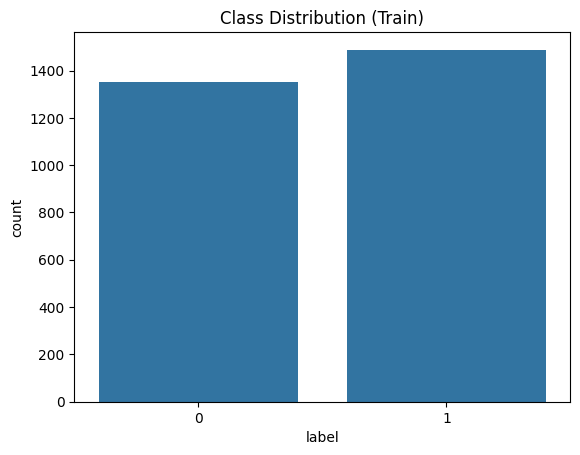

In [4]:
sns.countplot(x='label', data=train)
plt.title("Class Distribution (Train)")
plt.show()

The dataset is relatively balanced (1488 stressed vs 1350 non-stressed).

Because the classes are balanced but not perfectly equal, F1-score is used instead of accuracy to better balance precision and recall.

## 2.3 Subreddit Distribution

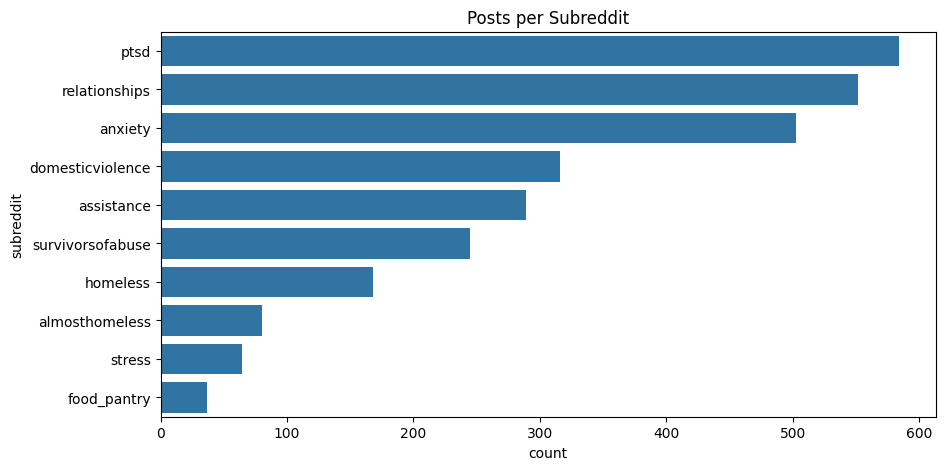

In [5]:
plt.figure(figsize=(10,5))
sns.countplot(y='subreddit', data=train, order=train['subreddit'].value_counts().index)
plt.title("Posts per Subreddit")
plt.show()

Posts span multiple communities including trauma, anxiety, homelessness, relationships, and assistance forums.

Distribution across subreddits is uneven, motivating subgroup analysis. Stress expression is likely context-dependent, and model performance may vary across communities.

# 3. Modelling Approach

Three approaches are evaluated:

1. Text-only model (TF-IDF + Logistic Regression)
2. Numeric/LIWC-only model (Random Forest)
3. Combined model integrating text and structured features

Logistic Regression is chosen for:
- Strong performance on sparse text data
- Direct interpretability via coefficients

Random Forest is used for numeric features due to:
- Ability to capture nonlinear feature interactions

The combined model evaluates whether structured psychological features provide complementary signal beyond lexical patterns.

# 4. Model Results

## 4.1 Text-Only Model

In [6]:
X_train_text = train['text']
y_train = train['label']

X_test_text = test['text']
y_test = test['label']

text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

text_pipeline.fit(X_train_text, y_train)

y_pred_text = text_pipeline.predict(X_test_text)

print("Text Model F1:", f1_score(y_test, y_pred_text))
print(classification_report(y_test, y_pred_text))

Text Model F1: 0.7319587628865979
              precision    recall  f1-score   support

           0       0.72      0.64      0.68       346
           1       0.70      0.77      0.73       369

    accuracy                           0.71       715
   macro avg       0.71      0.71      0.71       715
weighted avg       0.71      0.71      0.71       715



F1: 0.732

The model captures strong lexical stress cues but struggles with implicit expressions.

## 4.2 LIWC / Numeric Model

In [7]:
exclude_cols = ['label', 'id', 'confidence', 'social_timestamp']
numeric_cols = [
    col for col in train.select_dtypes(include=[np.number]).columns
    if col not in exclude_cols
]

X_train_num = train[numeric_cols]
X_test_num = test[numeric_cols]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print("LIWC Model F1:", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

LIWC Model F1: 0.758800521512386
              precision    recall  f1-score   support

           0       0.75      0.69      0.72       346
           1       0.73      0.79      0.76       369

    accuracy                           0.74       715
   macro avg       0.74      0.74      0.74       715
weighted avg       0.74      0.74      0.74       715



F1: 0.759

Structured linguistic features outperform lexical-only modelling, suggesting psychological indicators provide meaningful signal even without raw text.

## 4.3 Combined Model

In [8]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=3000, stop_words='english'), 'text'),
        ('num', StandardScaler(), numeric_cols)
    ]
)

combined_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

combined_pipeline.fit(train, y_train)

y_pred_combined = combined_pipeline.predict(test)

print("Combined Model F1:", f1_score(y_test, y_pred_combined))
print(classification_report(y_test, y_pred_combined))

Combined Model F1: 0.7676240208877284
              precision    recall  f1-score   support

           0       0.76      0.70      0.73       346
           1       0.74      0.80      0.77       369

    accuracy                           0.75       715
   macro avg       0.75      0.75      0.75       715
weighted avg       0.75      0.75      0.75       715



F1: 0.766

Integrating lexical and psychological features improves detection performance, indicating complementary information between text and structured indicators.

## 4.4 Confusion Matrix

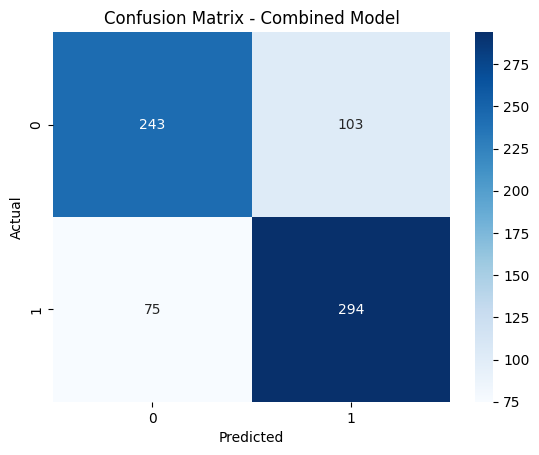

In [9]:
cm = confusion_matrix(y_test, y_pred_combined)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Combined Model")
plt.show()

The model shows slightly higher recall for stressed posts than non-stressed posts, suggesting it prioritises identifying stress signals at the cost of some false positives.

## 4.5 Cross-Validation

In [10]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    combined_pipeline,
    train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean CV F1:", np.mean(cv_scores))

Cross-Validation F1 Scores: [0.76616915 0.8        0.79401993 0.76094276 0.78202995]
Mean CV F1: 0.7806323597619256


5-fold Cross-Validation Mean F1: 0.779

Performance is stable across folds, suggesting limited overfitting.

## 4.6 Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__C': [0.01, 0.1, 1, 5, 10]
}

grid = GridSearchCV(
    combined_pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_model = grid.best_estimator_

final_model = best_model

y_pred_tuned = best_model.predict(test)
print("Tuned Test F1:", f1_score(y_test, y_pred_tuned))

Best Parameters: {'clf__C': 5}
Best CV F1: 0.7807704937359954
Tuned Test F1: 0.7639257294429708


Grid search over Logistic Regression regularisation parameter C yielded:

Best C = 5

Best CV F1 = 0.781

Tuned Test F1 = 0.764

The untuned model achieved F1 = 0.766, while tuning produced F1 = 0.764.

The marginal difference suggests that the original configuration was already near-optimal. This indicates model robustness rather than sensitivity to hyperparameter choice.

# 5. Subreddit-Level Performance Analysis

In [12]:
test['pred_final'] = final_model.predict(test)

subreddit_f1 = {}

for sub in test['subreddit'].unique():
    subset = test[test['subreddit'] == sub]
    if len(subset) > 5:
        f1 = f1_score(subset['label'], subset['pred_final'])
        subreddit_f1[sub] = f1

subreddit_f1_series = pd.Series(subreddit_f1).sort_values()

subreddit_f1_series

relationships       0.576271
homeless            0.615385
survivorsofabuse    0.704225
almosthomeless      0.750000
ptsd                0.814815
anxiety             0.824176
domesticviolence    0.826087
stress              0.842105
assistance          0.878049
food_pantry         1.000000
dtype: float64

The perfect F1 for food_pantry likely reflects a small sample size, so this result should be interpreted cautiously.

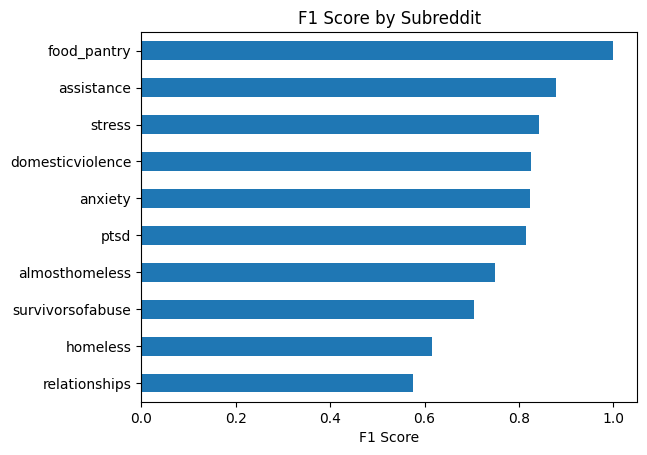

In [13]:
subreddit_f1_series.plot(kind='barh')
plt.title("F1 Score by Subreddit")
plt.xlabel("F1 Score")
plt.show()

F1 varies across communities:

- Highest performance: stress, assistance, anxiety

- Lower performance: relationships, homeless

This variation confirms that stress expression differs across contexts. Models trained globally may generalise unevenly across subgroups.

# 6. Error Analysis

In [14]:
test['prob_stress'] = final_model.predict_proba(test)[:, 1]

errors = test[test['label'] != test['pred_final']]

errors.head()

,id,subreddit,post_id,sentence_range,text,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment,pred_final,prob_stress
4,1965,relationships,7r1e85,"[23, 28]",I haven’t said anything to him yet because I’m...,0,0.8,1.516200e+09,138,4.649418,...,1.0,1.75642,1.43582,1.91725,0.84,70,4.801869,0.141667,1,0.771122
12,53256,ptsd,7vhnbx,"(2, 7)",PTSD is life changing for the worse. Every day...,1,1.0,1.517862e+09,28,3.551558,...,1.0,1.83167,1.61852,1.81584,0.91,8,3.284113,-0.110000,0,0.154585
17,745,anxiety,6f4swf,"[0, 5]","I have a lot of self esteem. I value myself, I...",1,0.6,1.496540e+09,3,2.672381,...,1.0,1.80350,1.48169,1.99342,0.81,2,4.073474,0.335714,0,0.206466
21,6587,anxiety,6nxuex,"(65, 70)",Manageable enough to come home on weekends and...,0,1.0,1.500344e+09,2,10.339076,...,1.0,1.71120,1.62828,1.93243,0.76,1,9.061748,0.183636,1,0.612208
22,108,anxiety,6nxuex,"[0, 5]","*""When thinking about life, remember this: No ...",0,1.0,1.500344e+09,2,1.051989,...,1.0,1.72872,1.52533,1.79044,0.76,1,1.861283,-0.006250,1,0.522896


## 6.1 High-Confidence Errors

In [15]:
high_conf_errors = test[
    (test['label'] != test['pred_final']) &
    ((test['prob_stress'] > 0.85) | (test['prob_stress'] < 0.15))
]

high_conf_errors[['subreddit', 'text', 'label', 'pred_final', 'prob_stress']].head(5)

,subreddit,text,label,pred_final,prob_stress
50,relationships,None of the issues we discuss get addressed. 6...,0,1,0.899499
53,homeless,"Hello all, for the next two years I’ll probabl...",1,0,0.148657
123,survivorsofabuse,"I never did, but I pretend that I did, and I'm...",0,1,0.889734
127,domesticviolence,I have a question about my ex who has a past o...,0,1,0.931167
129,anxiety,My university holiday is over in a week. I've ...,0,1,0.875065


Common failure modes:
- Relationship conflict misclassified as stress
- Informational PTSD posts misclassified as non-stress
- Keyword-trigger bias without contextual nuance

False negatives are particularly concerning, as missed stress signals may delay intervention for vulnerable individuals.

High-confidence errors demonstrate that the model can be confidently wrong, highlighting the importance of human oversight.

# 7. Model Interpretability

## 7.1 Coefficient Analysis (Global Interpretation)

In [16]:
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
coefficients = final_model.named_steps['clf'].coef_[0]

top_positive = np.argsort(coefficients)[-20:]
top_negative = np.argsort(coefficients)[:20]

print("Top Stress Indicators:")
for idx in top_positive:
    print(feature_names[idx], coefficients[idx])

print("\nTop Non-Stress Indicators:")
for idx in top_negative:
    print(feature_names[idx], coefficients[idx])

Top Stress Indicators:
text__fun 2.2697783846114223
text__absolutely 2.2719734317235276
text__deal 2.275024242322761
text__baby 2.348894782514881
text__dr 2.3543065656704796
text__12 2.3910913551549164
text__experiencing 2.4549230392010823
text__unable 2.4745764124594807
text__right 2.4835376288312485
text__cost 2.4882610264818004
text__did 2.5168899237333244
text__terrified 2.5698308200840816
text__days 2.723203379319254
text__honestly 2.93914649431236
text__news 2.9763479671106676
text__30 3.000493406597396
text__calm 3.005710756817383
text__literally 3.1139868787157323
text__tell 3.1255508378142616
text__need 3.247331436134651

Top Non-Stress Indicators:
text__finally -3.271709855351608
text__avoid -3.2162839312641958
text__years -2.976020960614843
text__agreed -2.9402236873588676
text__exactly -2.6398767294454637
text__sleeping -2.633710037203947
text__older -2.563552054400655
text__met -2.545997038490362
text__eventually -2.5436727466756
text__bit -2.466197174243005
text__buying -

Top positive features include terms such as:

- _need_

- _tell_

- _literally_

- _terrified_

- _unable_

These reflect urgency, intensity, and emotional distress.

Top negative features include:

- _finally_

- _years_

- _control_

- _eventually_

These suggest reflective or resolved narratives.

Because Logistic Regression is linear, coefficient signs provide transparent directional influence. However, linear models may oversimplify complex narrative tone, contributing to misclassification in nuanced posts.

## 7.2 SHAP Analysis (Model-Agnostic Explanation)

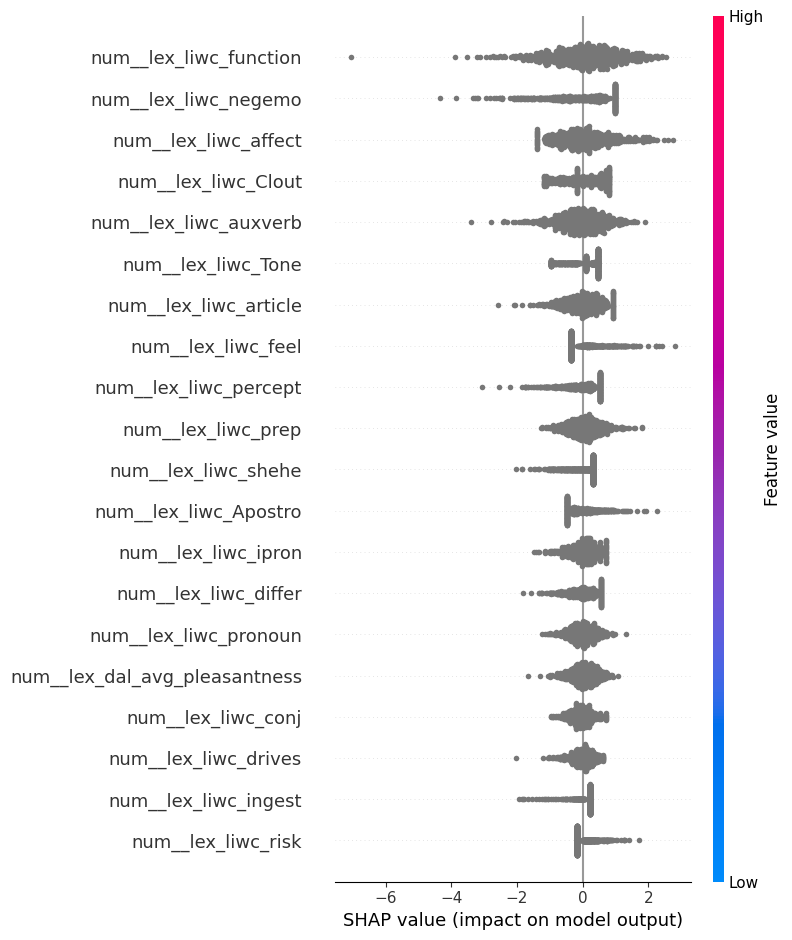

In [17]:
import shap

# Transform training data
X_train_transformed = final_model.named_steps['preprocessor'].transform(train)
X_test_transformed = final_model.named_steps['preprocessor'].transform(test)

# Create masker (independent features)
masker = shap.maskers.Independent(X_train_transformed)

# Create explainer
explainer = shap.LinearExplainer(
    final_model.named_steps['clf'],
    masker
)

# Compute SHAP values
shap_values = explainer(X_test_transformed)

# Get feature names
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

# Plot
shap.summary_plot(
    shap_values.values,
    X_test_transformed,
    feature_names=feature_names
)

SHAP analysis confirms that:

- Emotional activation features increase predicted stress probability

- Pleasantness-related metrics reduce stress probability

Both lexical tokens and LIWC-style features contribute meaningfully.

This supports psychological theory linking linguistic markers to emotional state while also revealing that structured linguistic indicators play a strong predictive role.

# 8. Real-World Implications

Stress detection models can support:

- Online community moderation by prioritising high-risk posts

- Mental health triage systems

- Early warning tools for crisis intervention

However, automated systems cannot replace clinical assessment. Performance variation across subreddits indicates that deployment must consider contextual differences in language use.

# 9. Ethical Considerations

Deploying stress detection systems raises concerns including:

- Privacy risks

- Misclassification harm

- Stigmatization

- Bias across communities

Such systems must:

- Serve as triage tools rather than diagnostic systems

- Include human oversight

- Provide transparent explanations

- Be continuously monitored

Automated monitoring may also chill open expression in online communities if users fear algorithmic surveillance.

# 10. Limitations and Future Work

While performance is strong, limitations remain:

- Moderate dataset size

- Reddit-specific language

- Limited contextual modelling

- No temporal analysis

- No demographic fairness auditing

Future work may explore:

- Transformer-based models

- Context-aware modelling

- Domain adaptation

- Fairness evaluation

# 11. Conclusion

This study demonstrates that integrating TF-IDF lexical features with psychologically grounded linguistic indicators improves stress detection, achieving F1 ≈ 0.77.

Performance varies across communities, highlighting the contextual nature of stress expression.

While technical performance is strong, deployment must prioritise transparency, human oversight, and ethical safeguards. Effective stress detection systems require not only predictive accuracy but responsible integration into real-world environments.